In [1]:
import json
import matplotlib.pyplot as plt
import sys
import numpy as np
plt.rcParams['text.usetex'] = (sys.platform == "darwin")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
plt.rcParams['font.size'] = 9

In [2]:
pde_configs = {
    'schrodinger': {'lb': 0.1, 'ub': 1.0, 'title': r'Schrodinger PDE', 'xlabel_param': r'\kappa'},
    'heat': {'lb': 1e-2, 'ub': 9e-2, 'title': r'Heat PDE', 'xlabel_param': r'\kappa'},
    'fokkerplanck': {'lb': 0.8, 'ub': 1.05, 'title': r'Fokker-Planck PDE', 'xlabel_param': r'\kappa'},
    'poisson2d': {'lb': 1e-2, 'ub': 0.5, 'title': r'2D Poisson PDE', 'xlabel_param': r'\kappa'},
}

data = {}
for type_, _ in pde_configs.items():
    with open(f'./models/pade_pinn_{type_}_error_metrics.json', 'r') as f:
        pade_pinn_metric = json.load(f)
    with open(f'./models/pinn_{type_}_error_metrics.json', 'r') as f:
        pinn_metric = json.load(f)

    pade_pinn_metric = dict(sorted(pade_pinn_metric.items(), key=lambda item: float(item[0])))
    kappa_vals = np.array([float(k) for k in pade_pinn_metric.keys()])

    y_pade_pinn = np.array([err['Rel_MSE'][1] for err in pade_pinn_metric.values()])
    y_pade_pinn_l2 = np.array([err['L2'][1] for err in pade_pinn_metric.values()])

    pinn_kappas = np.array([float(k) for k in pinn_metric.keys()])
    pinn_mse = np.array([v['Rel_MSE'] for v in pinn_metric.values()])
    pinn_l2 = np.array([v['L2'] for v in pinn_metric.values()])
    y_pinn = np.array([pinn_mse[np.argmin(np.abs(pinn_kappas - kv))] for kv in kappa_vals])
    y_pinn_l2 = np.array([pinn_l2[np.argmin(np.abs(pinn_kappas - kv))] for kv in kappa_vals])

    unique_kappas, unique_labels = [], []
    last_kv = -float('inf')
    min_dist = (kappa_vals[-1] - kappa_vals[0]) / 20.0
    for kv in kappa_vals:
        if kv - last_kv >= min_dist:
            unique_labels.append(f"{kv:.3f}")
            unique_kappas.append(kv)
            last_kv = kv

    data[type_] = {
        'kappa_vals': kappa_vals,
        'y_pade_pinn': y_pade_pinn,
        'y_pinn': y_pinn,
        'y_pade_pinn_l2': y_pade_pinn_l2,
        'y_pinn_l2': y_pinn_l2,
        'unique_kappas': unique_kappas,
        'unique_labels': unique_labels,
    }

In [3]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import importlib
import jax.numpy as jnp
import sympy as sp

time_series_pdes = ['schrodinger', 'heat', 'fokkerplanck', 'poisson2d']
cfg_class_names = {
    'schrodinger': 'SchrodingerConfig', 'heat': 'HeatConfig',
    'fokkerplanck': 'FokkerPlanckConfig', 'poisson2d': 'Poisson2DConfig',
}
time_data = {}

for type_ in time_series_pdes:
    d = data[type_]
    ratios = d['y_pinn'] / d['y_pade_pinn']
    worst_idx = int(np.argmax(ratios))
    kappa_test = float(d['kappa_vals'][worst_idx])

    pade_mod = importlib.import_module(f'pdes.{type_}.train_pade_pinn')
    pinn_mod = importlib.import_module(f'pdes.{type_}.train_pinn')
    cfg_mod = importlib.import_module(f'pdes.{type_}.config')
    cfg = getattr(cfg_mod, cfg_class_names[type_])()

    pade_model = pade_mod.PadePINN.load_model(f'models/pade_pinn_{type_}.pkl')
    pinn_model = pinn_mod.PINN.load_model(f'models/pinn_{type_}.pkl')

    if type_ == 'poisson2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, cfg.duration, cfg.nt_eval)[1:]
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

        x_sym, y_sym, t_sym, kappa_sym, u_initial, f_src_expr, pde_op = pade_mod.symbolic_poisson2d()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op, f_src=f_src_expr)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, kappa_test, X_grid, Y_grid, t_plot)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, X_grid, Y_grid, t_plot)
    else:
        endpoint = type_ != 'schrodinger'  # periodic domain excludes the right endpoint
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=endpoint)
        t_plot = np.linspace(cfg.starting_point, cfg.duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)

        if type_ == 'heat':
            x_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_heat()
            R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
            R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)
            u0 = pade_mod.uv_initial_condition(x_plot)
            res_pade = pade_mod.evaluate_kappa(pade_model, R, kappa_test, x_plot, t_plot, XT_flat_j, u0)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, x_plot, t_plot, XT_flat_np, u0)
        elif type_ == 'fokkerplanck':
            x_sym, t_sym, kappa_sym, p_initial, pde_op = pade_mod.symbolic_fokker_planck()
            R_expr, _ = pade_mod.compute_pade_time_32(p_initial, x_sym, t_sym, pde_op)
            R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)
            res_pade = pade_mod.evaluate_kappa(pade_model, R, kappa_test, x_plot, t_plot, XT_flat_j)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, x_plot, t_plot, XT_flat_np)
        else:  # schrodinger
            x_sym, t_sym, kappa_sym, u_initial, v_initial, pde_op_u, pde_op_v = pade_mod.symbolic_linearized_schrodinger()
            R_u, R_v, _, _ = pade_mod.compute_pade_time_22_pair(u_initial, v_initial, x_sym, t_sym, pde_op_u, pde_op_v)
            R_re = sp.lambdify((x_sym, t_sym, kappa_sym), R_u.evalf(), modules='jax')
            R_im = sp.lambdify((x_sym, t_sym, kappa_sym), R_v.evalf(), modules='jax')
            res_pade = pade_mod.evaluate_kappa(pade_model, R_re, R_im, kappa_test, x_plot, t_plot, XT_flat_j)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, x_plot, t_plot, XT_flat_np)

    errors_pade_t = np.asarray(res_pade['errors_nn'])
    errors_pinn_t = np.asarray(res_pinn['errors'])
    time_data[type_] = {
        'kappa': kappa_test,
        't_plot': np.asarray(t_plot),
        'l2_pade_pinn': errors_pade_t,
        'l2_pinn': errors_pinn_t,
        'mse_pade_pinn': errors_pade_t ** 2,
        'mse_pinn': errors_pinn_t ** 2,
    }

 f0_u = 0.8*cos(0.266666666666667*pi*x)   f0_v = 0
 f1_u = 0   f1_v = -0.0568888888888889*pi**2*kappa*cos(0.266666666666667*pi*x)
 f2_u = -0.00404543209876543*pi**4*kappa**2*cos(0.266666666666667*pi*x)   f2_v = 0
 f3_u = 0   f3_v = 0.000287675171467764*pi**6*kappa**3*cos(0.266666666666667*pi*x)
 f4_u = 2.04569010821521e-5*pi**8*kappa**4*cos(0.266666666666667*pi*x)   f4_v = 0
 b0_u = 1  (normalised)
 b1_u = 0
 b2_u = 0.000421399176954733*pi**4*kappa**2
 b0_v = 1  (normalised)
 b1_v = 0
 b2_v = 0.000842798353909465*pi**4*kappa**2
 P[2/2](x,t) = (-0.00168559670781893*pi**4*kappa**2*t**2*cos(0.266666666666667*pi*x) + 0.8*cos(0.266666666666667*pi*x))/(0.000421399176954733*pi**4*kappa**2*t**2 + 1)
 P[2/2](x,t) = -0.0568888888888889*pi**2*kappa*t*cos(0.266666666666667*pi*x)/(0.000842798353909465*pi**4*kappa**2*t**2 + 1)
Model loaded ← models/pade_pinn_schrodinger.pkl
Model loaded from models/pinn_schrodinger.pkl
 f0_u = 0.8*cos(0.266666666666667*pi*x)   f0_v = 0
 f1_u = 0   f1_v = -0.05688888

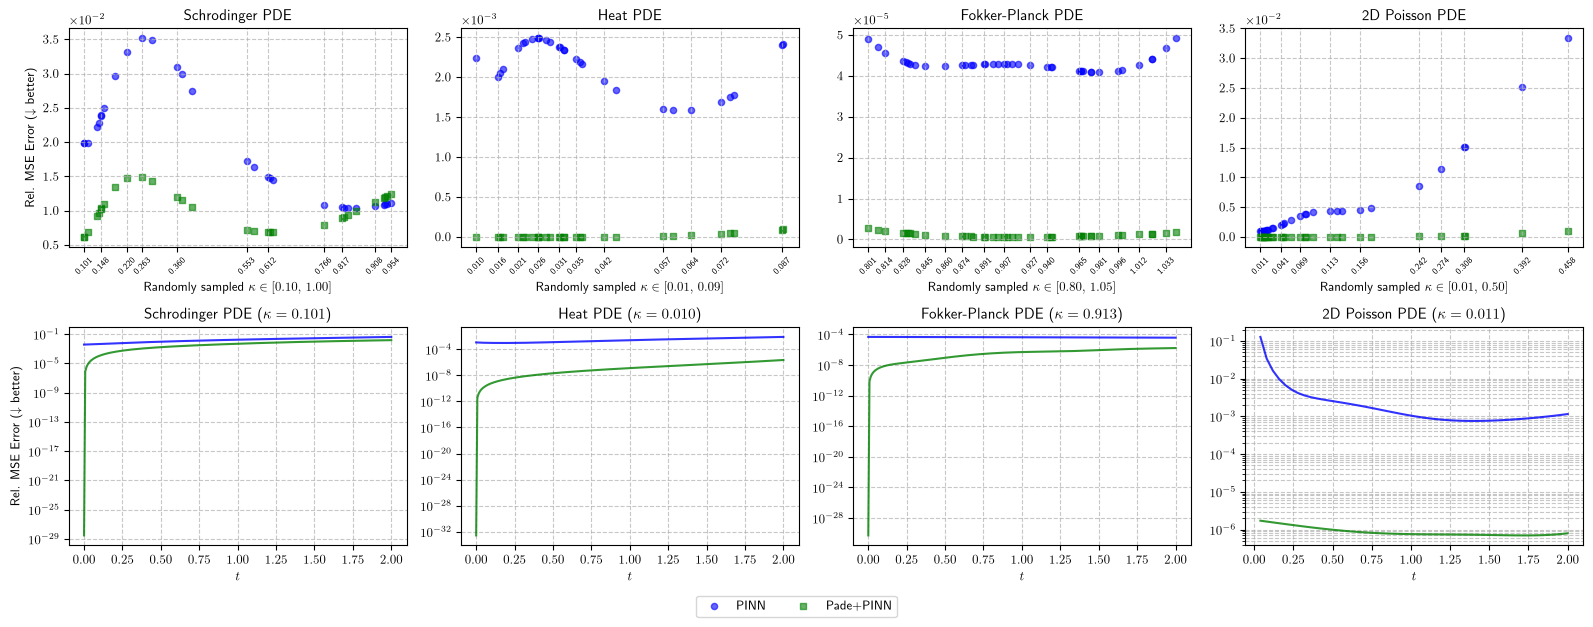

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

handles = None
for ax, (type_, cfg) in zip(axes[0], pde_configs.items()):
    d = data[type_]
    kappa_vals = d['kappa_vals']
    y_pade_pinn, y_pinn = d['y_pade_pinn'], d['y_pinn']

    h1 = ax.scatter(kappa_vals, y_pinn, label="PINN", color='blue', alpha=0.6, marker='o', s=20)
    h2 = ax.scatter(kappa_vals, y_pade_pinn, label=r"Pade+PINN", color='green', alpha=0.6, marker='s', s=20)
    if handles is None:
        handles = [h1, h2]
        labels  = ["PINN", r"Pade+PINN"]

    ax.set_xlabel(fr'Randomly sampled ${cfg["xlabel_param"]} \in [{cfg["lb"]:.2f},\, {cfg["ub"]:.2f}]$')
    ax.set_title(cfg['title'])
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    ax.set_xticks(d['unique_kappas'])
    ax.set_xticklabels(d['unique_labels'], rotation=45, fontsize=6)
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

axes[0, 0].set_ylabel(r'Rel. MSE Error ($\downarrow$ better)')

for ax, type_ in zip(axes[1], time_series_pdes):
    td = time_data[type_]
    ax.semilogy(td['t_plot'], td['mse_pinn'], color='blue', alpha=0.8, linewidth=1.5, label='PINN')
    ax.semilogy(td['t_plot'], td['mse_pade_pinn'], color='green', alpha=0.8, linewidth=1.5, label='Pade+PINN')
    ax.set_xlabel(r'$t$')
    ax.set_title(fr'{pde_configs[type_]["title"]}  ($\kappa={td["kappa"]:.3f}$)')
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

axes[1, 0].set_ylabel(r'Rel. MSE Error ($\downarrow$ better)')

fig.legend(labels, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.045), frameon=True)
plt.tight_layout()
plt.savefig('./figs/error/padepinn_vs_pinn_error_comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()

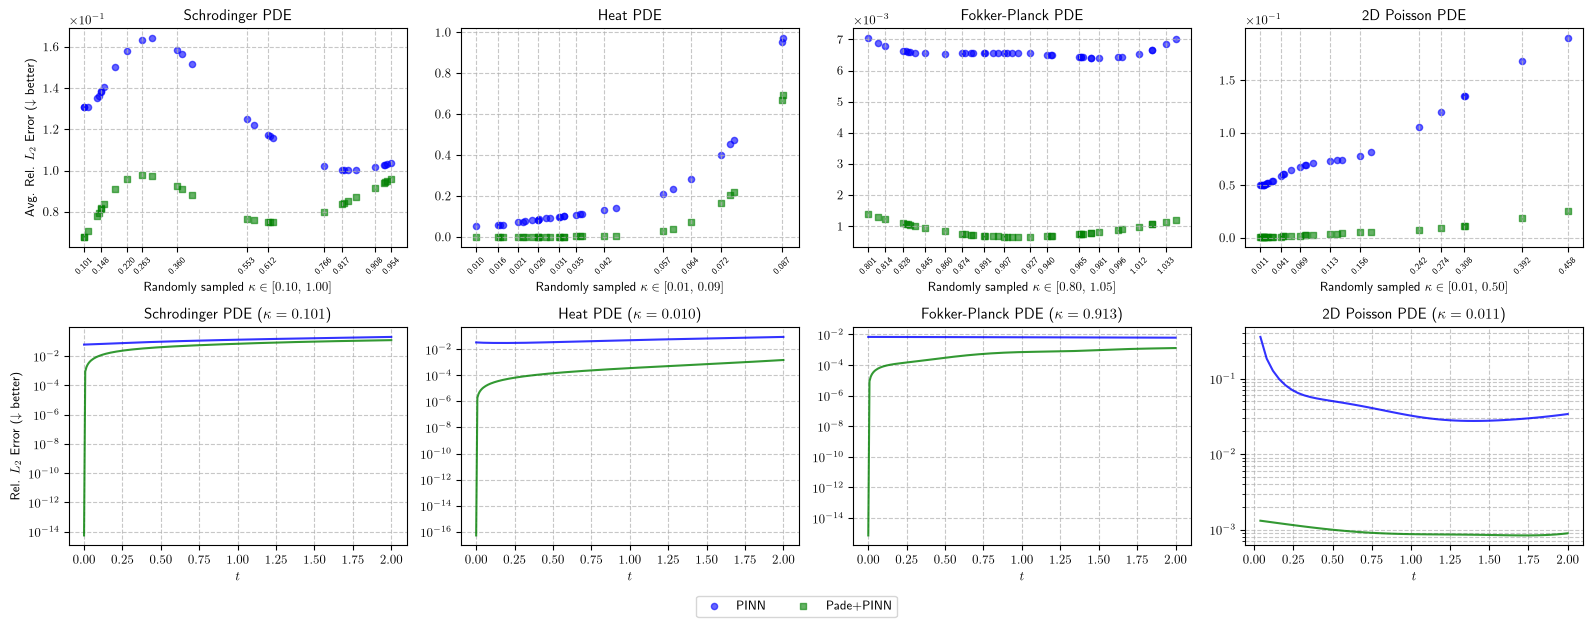

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for ax, (type_, cfg) in zip(axes[0], pde_configs.items()):
    d = data[type_]
    kappa_vals = d['kappa_vals']
    y_pade_pinn_l2, y_pinn_l2 = d['y_pade_pinn_l2'], d['y_pinn_l2']

    ax.scatter(kappa_vals, y_pinn_l2, label="PINN", color='blue', alpha=0.6, marker='o', s=20)
    ax.scatter(kappa_vals, y_pade_pinn_l2, label=r"Pade+PINN", color='green', alpha=0.6, marker='s', s=20)

    ax.set_xlabel(fr'Randomly sampled ${cfg["xlabel_param"]} \in [{cfg["lb"]:.2f},\, {cfg["ub"]:.2f}]$')
    ax.set_title(cfg['title'])
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    ax.set_xticks(d['unique_kappas'])
    ax.set_xticklabels(d['unique_labels'], rotation=45, fontsize=6)
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

axes[0, 0].set_ylabel(r'Avg. Rel. $L_2$ Error ($\downarrow$ better)')

for ax, type_ in zip(axes[1], time_series_pdes):
    td = time_data[type_]
    ax.semilogy(td['t_plot'], td['l2_pinn'], color='blue', alpha=0.8, linewidth=1.5, label='PINN')
    ax.semilogy(td['t_plot'], td['l2_pade_pinn'], color='green', alpha=0.8, linewidth=1.5, label='Pade+PINN')
    ax.set_xlabel(r'$t$')
    ax.set_title(fr'{pde_configs[type_]["title"]}  ($\kappa={td["kappa"]:.3f}$)')
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

axes[1, 0].set_ylabel(r'Rel. $L_2$ Error ($\downarrow$ better)')

fig.legend(labels, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.045), frameon=True)
plt.tight_layout()
plt.savefig('./figs/error/padepinn_vs_pinn_l2_error_comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()